# MNIST EDA

In [1]:
# ставим относительный путь

from pathlib import Path
import os

os.chdir(Path("..").resolve())
print(Path.cwd())


/Users/aleksandr/ser/speech-emo-recognition


In [2]:
# ставим конфиг

from src.dataset import MNISTDataset
from src.plot import (
    plot_class_distribution,
    plot_duration_distribution,
    plot_log_mel_spectrogram,
    plot_mel_filter_bank,
    plot_spectrogram_db,
    set_plot_theme,
    show_spectrogram,
    show_waveform,
)
import torchaudio

from pathlib import Path
import os
from IPython.display import Audio

from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf

set_plot_theme()

GlobalHydra.instance().clear()

with initialize_config_dir(
    version_base="1.3",
    config_dir="/Users/aleksandr/ser/speech-emo-recognition/configs",
):
    cfg = compose(config_name="config")

print(OmegaConf.to_yaml(cfg))


/Users/aleksandr/ser/speech-emo-recognition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


dataset:
  name: AudioMNIST
  paths:
    hf_path: gilkeyio/AudioMNIST
    local_path: data/AudioMNIST
  sample_rate: 16000
feature:
  extractors:
  - name: log_mel
    params:
      n_fft: 2048
      hop_length: 512
      n_mels: 80
      window: hann
  - name: mfcc
    params:
      n_fft: 2048
      hop_length: 512
      n_mels: 80
      n_mfcc: 40
      window: hann
experiment_name: audio_mnist_baseline
dataloader:
  batch_size: 32
  num_workers: 0
  shuffle: true
  dev_size: 0.1
  test_size: 0.2
train:
  seed: 42
  epochs: 10
  learning_rate: 0.001
  device: cpu
seed: 42



In [3]:
dataset = MNISTDataset(split='train')

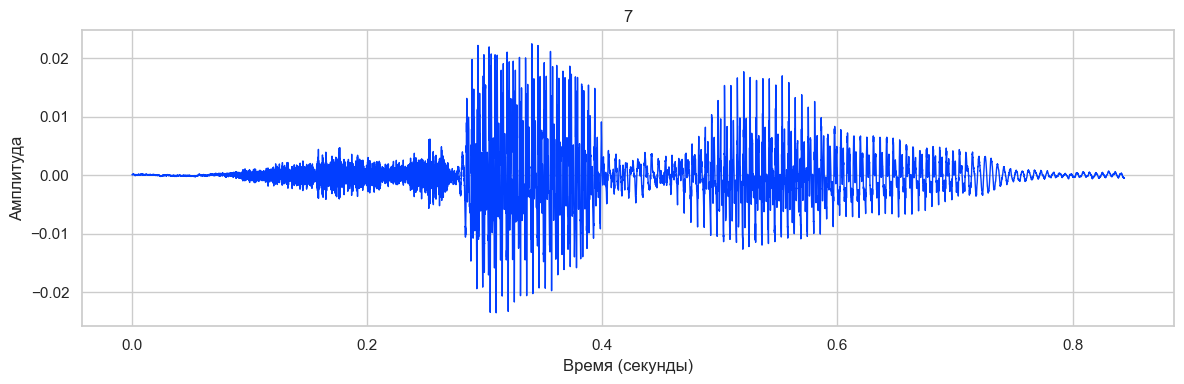

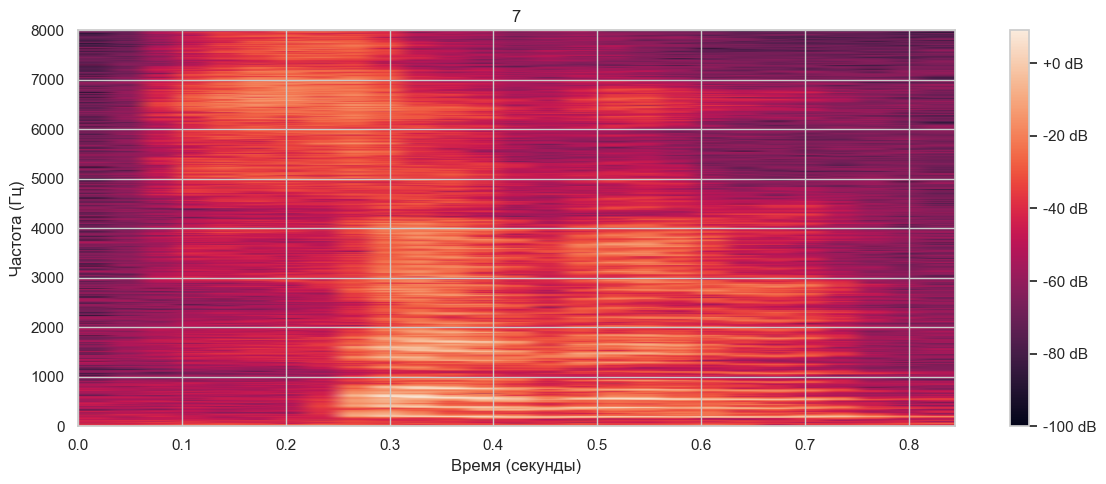

In [4]:
wav = dataset[1][0]
label = dataset[1][1]
sr = cfg.dataset.sample_rate

show_waveform(wav, label, sr=sr)
show_spectrogram(wav, label, sr=sr)
Audio(wav, rate=sr)

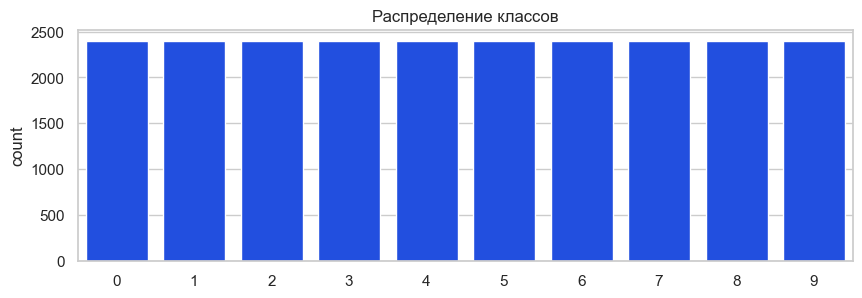

In [5]:
plot_class_distribution(dataset.labels)

In [7]:
from tqdm import tqdm

durations = []

for i in tqdm(range(len(dataset))):
    duration = round((len(dataset[i][0]) / sr), 3)
    durations.append(duration)

100%|██████████| 24000/24000 [01:59<00:00, 200.79it/s]


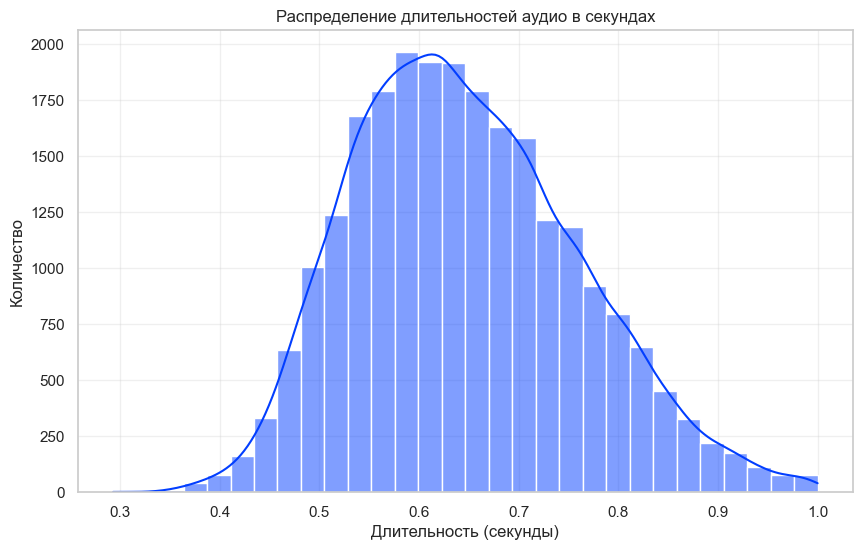

In [8]:
plot_duration_distribution(durations)

In [9]:
sr_counter = {}

for i in tqdm(range(len(dataset))):
    sr_counter[dataset[i][2]] = sr_counter.get(dataset[i][2], 0) + 1

100%|██████████| 24000/24000 [03:46<00:00, 105.93it/s]


In [10]:
assert len(sr_counter.values()) == 1, "Sampling Rate of all sanples is not similar"

In [6]:
n_fft = 2048
hop_length = 512

spec = torchaudio.transforms.Spectrogram(
    n_fft=n_fft,
    hop_length=hop_length,
    power=2.0,
)(wav)  # shape: [1 + n_fft // 2, time]


Shape: (8, 1025)


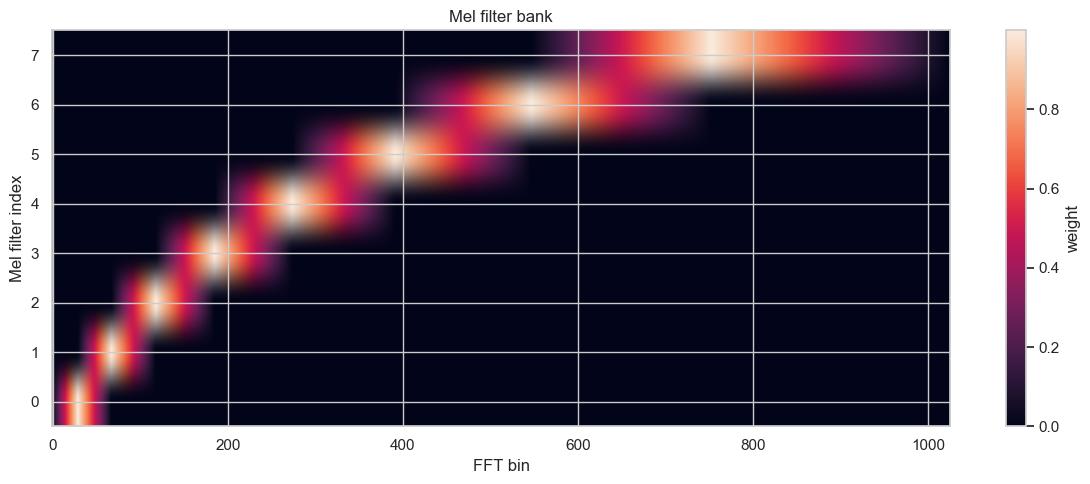

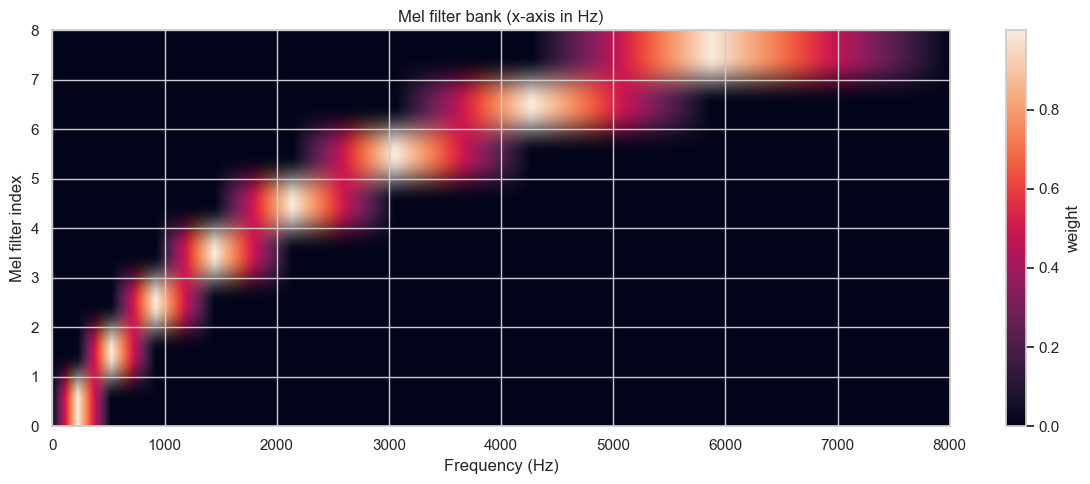

In [7]:
# Параметры
sr = 16000
n_fft = 2048
hop_length = 512
n_mels = 8
fmin = 0
fmax = sr / 2

mel_fb = torchaudio.functional.melscale_fbanks(
    n_freqs=1 + n_fft // 2,
    f_min=fmin,
    f_max=fmax,
    n_mels=n_mels,
    sample_rate=sr,
).T

print("Shape:", tuple(mel_fb.shape))
plot_mel_filter_bank(mel_fb, fmin=fmin, fmax=fmax)


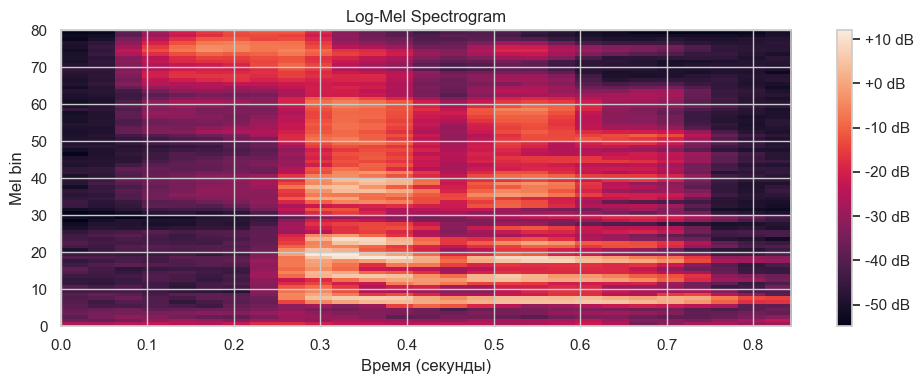

In [8]:
mel_spec = torchaudio.transforms.MelSpectrogram(
    sample_rate=sr,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=80,
    power=2.0,
)(wav)
log_mel_spec = torchaudio.transforms.AmplitudeToDB(stype="power")(mel_spec)

plot_log_mel_spectrogram(log_mel_spec, sr=sr, num_samples=wav.numel())


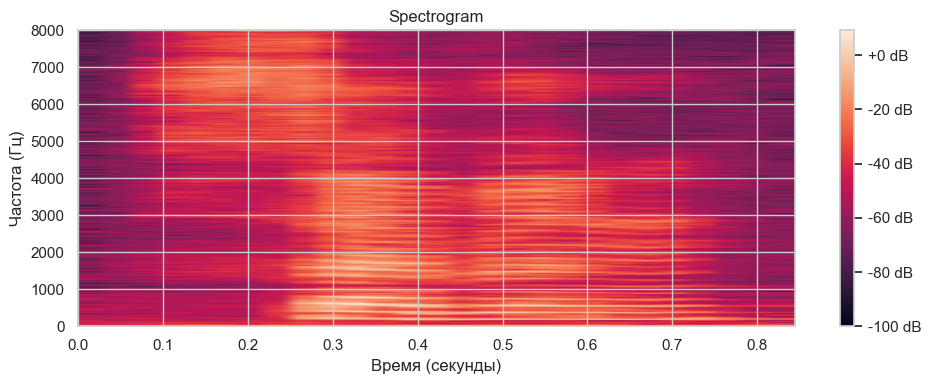

In [9]:
spec_db = torchaudio.transforms.AmplitudeToDB(stype="power")(spec)
plot_spectrogram_db(spec_db, sr=sr, num_samples=wav.numel())

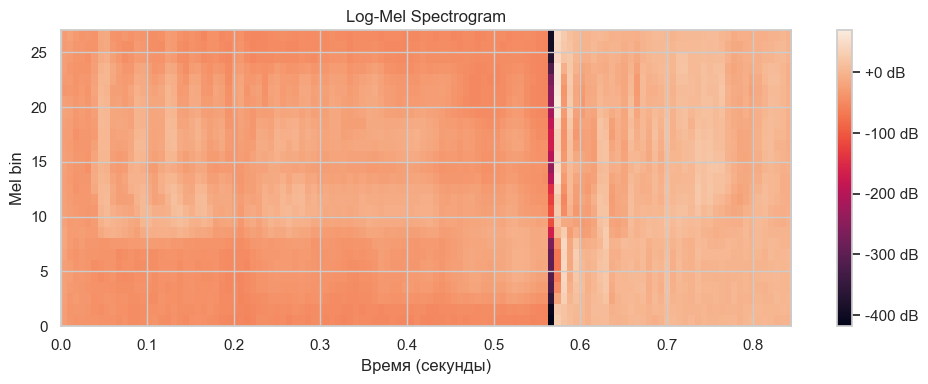

In [10]:
from src.features import get_features

# только log_mel
feats = get_features(wav, cfg)
plot_log_mel_spectrogram(feats, sr=sr, num_samples=wav.numel())

In [11]:
feats.shape

torch.Size([27, 120])

In [12]:
from src.loader import create_dataloaders

train_loader, dev_loader, test_loader = create_dataloaders(cfg)

In [ ]:
wavs, labels = next(iter(train_loader))

In [14]:
wavs.shape

torch.Size([32, 13037])

In [15]:
labels

tensor([1, 2, 2, 2, 3, 0, 1, 8, 0, 7, 4, 0, 5, 2, 0, 3, 8, 2, 6, 9, 2, 1, 4, 8,
        4, 4, 4, 2, 0, 0, 6, 5])

In [16]:
feats = get_features(wavs, cfg)

In [17]:
feats.shape

torch.Size([32, 26, 120])